In [20]:
import torch 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import os
outdir = r"C:\Document\Serieux\Travail\python_work\cEBNM_torch\notebooks\cEBMF_test\hierarchical_factor_model"
from pathlib import Path

outdir_sim = Path(
    r"C:\Document\Serieux\Travail\python_work\cEBNM_torch\notebooks"
    r"\cEBMF_test\hierarchical_factor_model\sim_mat"
)


outdir_sim2 = Path(
    r"C:/Document/Serieux/Travail/Data_analysis_and_papers/bencmark_cebmf/cEBMF_sim_and_fit"
)
outdir_sim.mkdir(parents=True, exist_ok=True)
 
os.makedirs(outdir_sim, exist_ok=True)
os.makedirs(outdir, exist_ok=True)
# Reproducibility
from cebmf_torch import cEBMF

In [ ]:
import numpy as np

def reconstruction_rmse(L_est, F_est, X_true):
    """RMSE between reconstructed signal L_est @ F_est and the true noiseless signal."""
    X_hat = (L_est @ F_est).detach().cpu().numpy()
    X_true_np = X_true.detach().cpu().numpy()
    return np.sqrt(np.mean((X_hat - X_true_np) ** 2))

res_no_warm = list()
res_warm = list()

rmse_no_warm_cold = list()   # mycebmf2 (cgb_sharp_2, no warm start)
rmse_no_warm_warm = list()   # mycebmf21 (cgb_sharp_2, warm-started from mycebmf1)

for i in range(10):
    N = 2000
    P = 200
    torch.manual_seed(i)

    t0 = torch.randint(0, 2, (P,), dtype=torch.float32)
    t1 = torch.randint(0, 2, (P,), dtype=torch.float32)
    t2 = torch.randint(0, 2, (P,), dtype=torch.float32)
    t11 = torch.randint(0, 2, (P,), dtype=torch.float32)
    t12 = torch.randint(0, 2, (P,), dtype=torch.float32)
    t21 = torch.randint(0, 2, (P,), dtype=torch.float32)
    t22 = torch.randint(0, 2, (P,), dtype=torch.float32)

    a0 = t0 * torch.randn(P)
    b1 = t1 * torch.randn(P)
    b2 = t2 * torch.randn(P)
    detla11 = t11 * torch.randn(P)
    detla12 = t11 * torch.randn(P)
    detla21 = t11 * torch.randn(P)
    detla22 = t11 * torch.randn(P)

    f_mat = torch.stack([a0, b1, b2, detla11, detla12, detla21, detla22], dim=0)

    N = 1000
    L = torch.zeros(N, 7, dtype=torch.float32)
    L[:, 0] = 1
    L[0:500, 1] = 1
    L[500:, 2] = 1
    L[0:250, 3] = 1
    L[251:500, 4] = 1
    L[501:750, 5] = 1
    L[751:, 6] = 1

    X_true = L @ f_mat
    Z = L @ f_mat + 0.5 * torch.randn(N, P) * 2.5
    Z_np = Z.detach().cpu().numpy()

    X_np = X_true.detach().cpu().numpy()
# Save as tab-delimited text
    #np.savetxt(os.path.join(outdir, "Z_matrix.txt"), Z_np, fmt="%.6f", delimiter="\t")
  

# Save as tab-delimited text
    np.savetxt(
    outdir_sim / f"Z_matrix_{i}.txt",
    Z_np,
    fmt="%.6f",
    delimiter="\t"
    )

    np.savetxt(
    outdir_sim2 / f"Z_matrix_{i}.txt",
    Z_np,
    fmt="%.6f",
    delimiter="\t"
    )

    np.savetxt(
    outdir_sim / f"X_matrix_{i}.txt",
    X_np,
    fmt="%.6f",
    delimiter="\t"
    )
    np.savetxt(
    outdir_sim2 / f"X_matrix_{i}.txt",
    X_np,
    fmt="%.6f",
    delimiter="\t"
    )     
   # --- cold start ---
    mycebmf2 = cEBMF(data=Z, self_row_cov=True,
                      prior_L="cgb_sharp", K=5,
                      allow_backfitting=False,
                        prior_L_kwargs={"penalty": 1.011, 
                                        "omega":0.01})
    mycebmf2.initialise_factors()
    mycebmf2.fit(10 )
   
    rmse_no_warm_cold.append(  torch.sqrt(torch.mean( (X_true -mycebmf2.L@  mycebmf2.F.T)**2)))
 
    # --- short cgb run used only to warm-start ---
     # --- short cgb run used only to warm-start ---
    mycebmf1 = cEBMF(data=Z, self_row_cov=True,
                      prior_L="cgb", K=5,
                      allow_backfitting=False,
                        prior_L_kwargs={"penalty": 1.051})
    mycebmf1.initialise_factors()
    mycebmf1.fit(10 )

    res_no_warm.append(mycebmf2.L)
    # --- warm start ---
    mycebmf21 = cEBMF(data=Z, self_row_cov=True,
                       prior_L="cgb_sharp_2", K=5,
                       allow_backfitting=False,
                        prior_L_kwargs={"penalty": 1.0111, 
                                        "omega":0.01})
    mycebmf21.initialise_factors( L=mycebmf1.L, F=mycebmf1.F)
    mycebmf21.fit(20)

 
    res_no_warm.append(mycebmf21.L)   # kept to match your original code
    res_warm.append(mycebmf21.L)
    rmse_no_warm_warm.append(torch.sqrt(  torch.mean( (X_true -mycebmf21.L@  mycebmf21.F.T)**2)))

    fit_cebmf_out=mycebmf21.L@  mycebmf21.F.T  

 

    np.savetxt(
    outdir_sim2 / f"L_cebmf_{i}.txt",
    mycebmf21.L,
    fmt="%.6f",
    delimiter="\t"
    )

    np.savetxt(
    outdir_sim2 / f"fit_cebmf_{i}.txt",
      fit_cebmf_out ,
    fmt="%.6f",
    delimiter="\t"
    )    
    print(i)
    print( rmse_no_warm_warm)

    print( rmse_no_warm_cold)
    
rmse_no_warm_cold = torch.stack(rmse_no_warm_cold)
rmse_no_warm_warm = torch.stack(rmse_no_warm_warm)



[CGB] Epoch 10/10, Loss=37.0193, mu2=-0.080, sigma2=0.891
[CGB] Epoch 10/10, Loss=22.6818, mu2=-0.034, sigma2=0.621
[CGB] Epoch 10/10, Loss=9.5562, mu2=0.050, sigma2=0.365
[CGB] Epoch 10/10, Loss=8.0772, mu2=0.001, sigma2=0.321
[CGB] Epoch 10/10, Loss=2.1857, mu2=-0.001, sigma2=0.094
[CGB] Epoch 10/10, Loss=32.0252, mu2=-0.160, sigma2=0.311
[CGB] Epoch 10/10, Loss=19.1669, mu2=-0.056, sigma2=0.141
[CGB] Epoch 10/10, Loss=5.8486, mu2=0.142, sigma2=0.046
[CGB] Epoch 10/10, Loss=5.1723, mu2=-0.022, sigma2=0.041
[CGB] Epoch 10/10, Loss=2.1807, mu2=-0.000, sigma2=0.000
[CGB] Epoch 10/10, Loss=25.0341, mu2=-0.240, sigma2=0.092
[CGB] Epoch 10/10, Loss=14.0933, mu2=-0.141, sigma2=0.024
[CGB] Epoch 10/10, Loss=-0.2224, mu2=0.214, sigma2=0.007
[CGB] Epoch 10/10, Loss=-0.8832, mu2=-0.088, sigma2=0.002
[CGB] Epoch 10/10, Loss=-7.2397, mu2=0.006, sigma2=0.000
[CGB] Epoch 10/10, Loss=8.6716, mu2=-0.317, sigma2=0.020
[CGB] Epoch 10/10, Loss=2.3707, mu2=-0.212, sigma2=0.004
[CGB] Epoch 10/10, Loss=-1.

In [ ]:
print(f"Cold start RMSE:  mean={rmse_no_warm_cold.mean():.4f}, sd={rmse_no_warm_cold.std():.4f}")
print(f"Warm start RMSE:  mean={rmse_no_warm_warm.mean():.4f}, sd={rmse_no_warm_warm.std():.4f}")

AttributeError: 'list' object has no attribute 'mean'

In [ ]:
print(rmse_no_warm_warm)
print(rmse_no_warm_cold)

[tensor(0.0759), tensor(0.4139), tensor(0.0768), tensor(0.0733)]
[tensor(0.0852), tensor(0.1880), tensor(0.0967), tensor(0.0819)]


In [ ]:
i=0

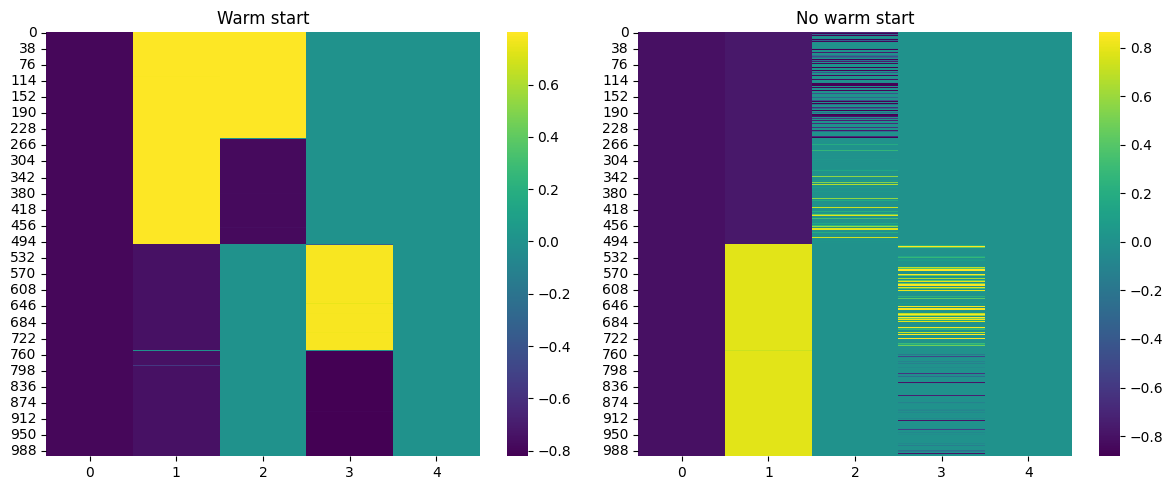

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    res_warm[i],
    cmap="viridis",
    annot=False,
    ax=axes[0]
)
axes[0].set_title("Warm start")

# Second heatmap
sns.heatmap(
     res_no_warm[i],
    cmap="viridis",
    annot=False,
    ax=axes[1]
)
axes[1].set_title("No warm start")

plt.tight_layout()
plt.show()
i=i+1

In [ ]:
i


1

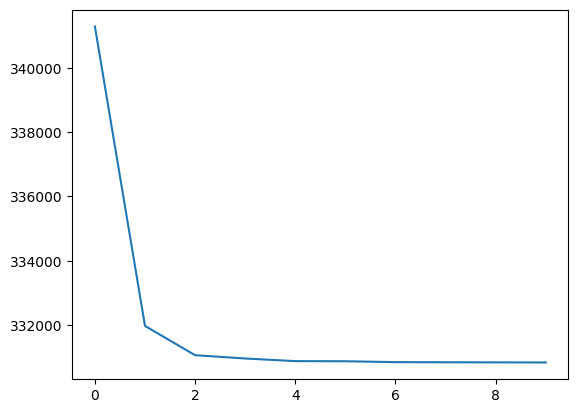

In [ ]:
plt.plot(mycebmf21.obj)